In [2]:
import pymongo
import os
from dotenv import load_dotenv

load_dotenv()

client = pymongo.MongoClient(os.getenv('MONGO_URI'))
db = client['Logs']
collection = db['queries']
db.list_collection_names()

['queries']

In [1]:
# from datetime import datetime
# for p in collection.find({"username": "Katerina"},sort=[("time", pymongo.DESCENDING)]):
#     time_format = datetime.fromtimestamp(p['time']/1e9).strftime("%d-%m-%y %H:%M:%S")
#     if p['system'] =='task_start':
#         print(time_format, p['query'] )
#     else:
#         print(time_format,  p['system'], f"{p['match']}%",":", p['query'])

In [3]:
usernames = []

users = {}
groups = {1:[], 2:[]}
for user in usernames:
    users[user] = {}
    u = users[user]
    for p in collection.find({"username": user},sort=[("time", pymongo.ASCENDING)]):
        sys = p['system']
        sys = "manually" if sys == "input" else sys
        if (sys =='task_start' and p['query'] in ["Task 1","Task 2"]):
            continue
        elif (p['task']=="Done!"):
            groups[p['group']].append(user)
            
        else:
            t = round(p['time']/1e9)
            if p['task'] not in u:
                u[p['task']]=[[t,0,sys]]
            else:
                u[p['task']].append([t,p['match'],sys])


for user in users:
    for task,v in users[user].items():
        # print(task,v)
        score = max([s[1] for s in v])
        time = round((v[-1][0] - v[0][0])/60,1)
        users[user][task] = {"score": score, "system": v[-1][2], "time": time, "steps": len(v) }

print(groups)
# print("1:", len(groups[1]), ",     2:", len(groups[2]))


{1: [], 2: []}


In [10]:
import pandas as pd
import seaborn as sns
import tikzplotlib
import matplotlib.pyplot as plt

def tikzplotlib_fix_ncols(obj):
    """
    workaround for matplotlib 3.6 renamed legend's _ncol to _ncols, which breaks tikzplotlib
    """
    if hasattr(obj, "_ncols"):
        obj._ncol = obj._ncols
    for child in obj.get_children():
        tikzplotlib_fix_ncols(child)

tasks = []
for user in users:
    for task,v in users[user].items():
        tasks.append([task, v["system"],v['score'],v['time'],v['steps'], v['score']==100 ])

df = pd.DataFrame(tasks, columns=["Task", "System","Score","Time","Steps","Completed"])
print("Successful Manual Tasks:", round(len(df[(df['Completed']==True) & (df['System']=="manually")])/len(df[df['System']=="manually"])*100),'%')
print("Successful QB Tasks:",round(len(df[(df['Completed']==True) & (df['System']=="QB")])/len(df[df['System']=="QB"])*100),'%')

Successful Manual Tasks: 71 %
Successful QB Tasks: 90 %


In [11]:
# ax = sns.countplot(x='System', data=df[df['Completed']==True])
# ax.set(ylabel="Successful Tasks")

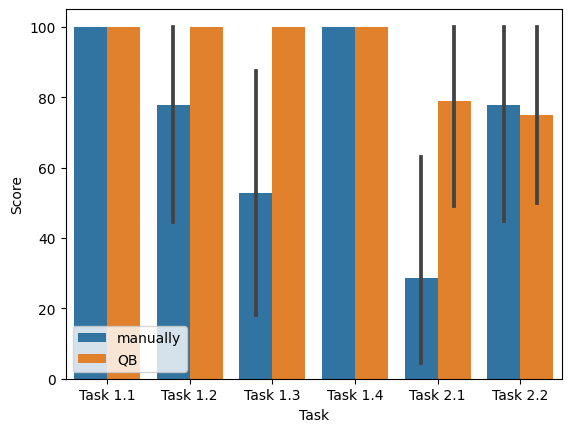

In [10]:
ax = sns.barplot(data=df, x="Task", y="Score", hue="System")
leg = plt.legend(title="")
tikzplotlib_fix_ncols(leg)

tikzplotlib.save(
            "scores.tex",
            extra_axis_parameters=["scaled x ticks=false", "scaled y ticks=false"],
            axis_height="\\figH",
            axis_width="\\figW",
        )

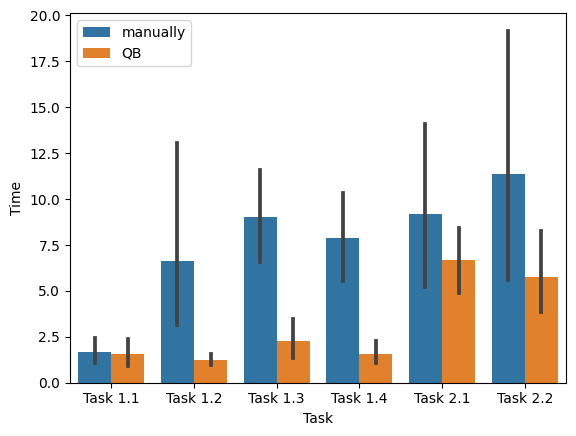

In [11]:
ax = sns.barplot(data=df, x="Task", y="Time", hue="System")
leg = plt.legend(title="")

tikzplotlib_fix_ncols(leg)

tikzplotlib.save(
            "time.tex",
            extra_axis_parameters=["scaled x ticks=false", "scaled y ticks=false"],
            axis_height="\\figH",
            axis_width="\\figW",
        )

In [117]:
# sns.barplot(data=df, x="Task", y="Steps", hue="System")